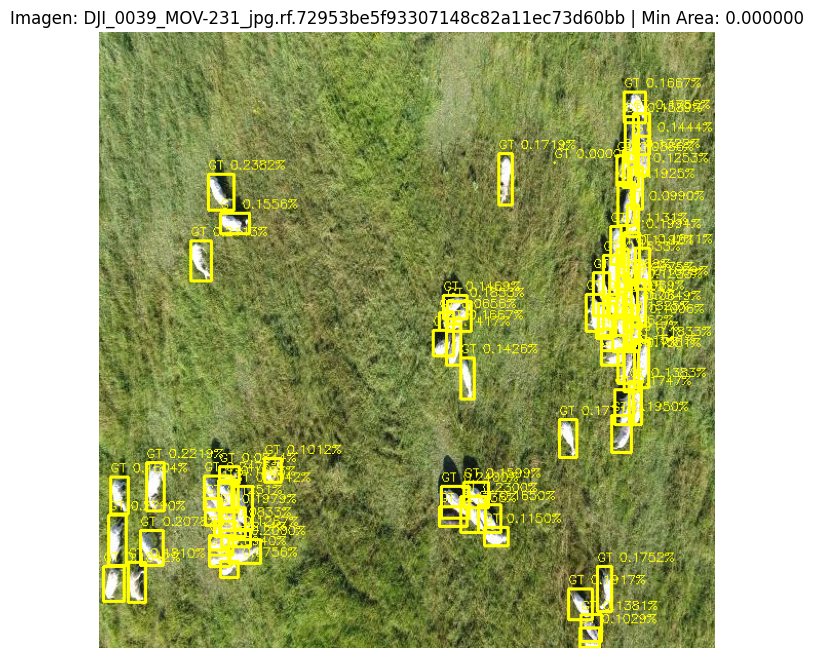

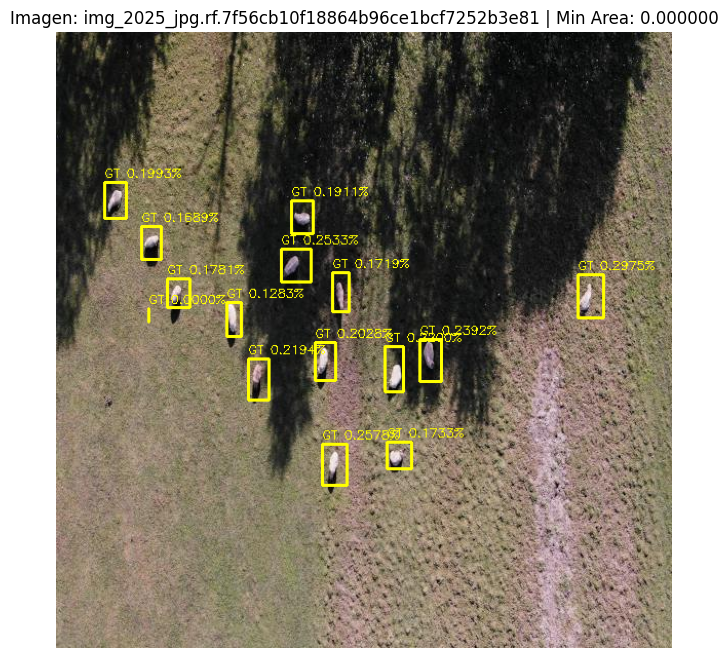

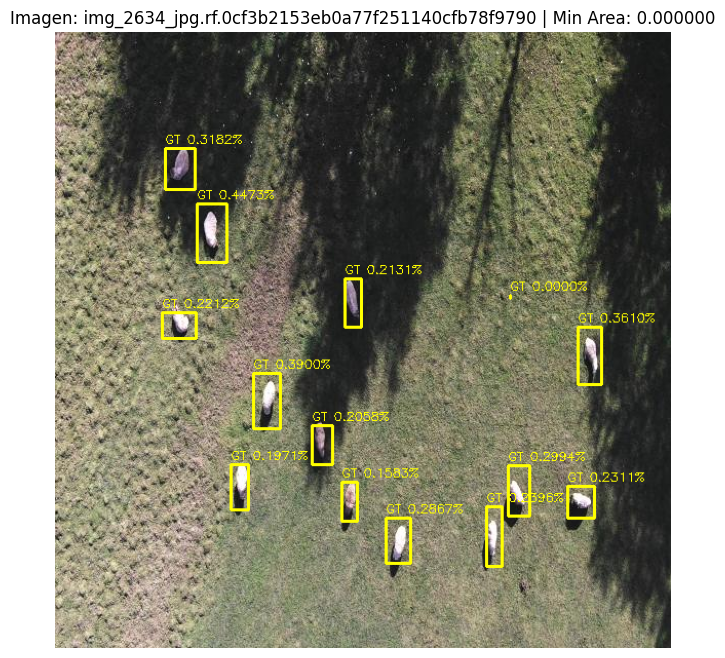

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- CONFIGURACIÓN ---
LABEL_DIR = "../WAID/labels/test"
IMAGE_DIR = "../WAID/images/test"
MODELO_PATH = "../ModelsWAID/WAID_11m_4.pt"

SMALL_MAX_AREA = 0.001  # Umbral de área pequeña
TOP_K = 3              # Cuántas imágenes mostrar

# Cargar modelo una sola vez para ahorrar tiempo
model = YOLO(MODELO_PATH)

def obtener_imagenes_pequenas(label_dir, image_dir, threshold=0.1, top_k=20):
    """Retorna lista de dicts con imágenes que tienen objetos bajo el umbral de área."""
    encontradas = []
    for fname in sorted(os.listdir(label_dir)):
        if not fname.endswith(".txt"): continue
        
        img_id = os.path.splitext(fname)[0]
        label_path = os.path.join(label_dir, fname)
        
        # Buscar imagen (soporta jpg y png)
        img_path = None
        for ext in [".jpg", ".png", ".jpeg"]:
            tmp = os.path.join(image_dir, img_id + ext)
            if os.path.exists(tmp):
                img_path = tmp
                break
        
        if not img_path: continue

        with open(label_path, "r") as f:
            areas = [float(line.split()[3]) * float(line.split()[4]) for line in f if len(line.split()) >= 5]
        
        small_objs = [a for a in areas if a <= threshold]
        if small_objs:
            encontradas.append({
                "id": img_id,
                "img_path": img_path,
                "label_path": label_path,
                "min_area": min(small_objs)
            })

    return sorted(encontradas, key=lambda x: x["min_area"])[:top_k]

def analizar_y_dibujar(info, conf=0.1):
    # --- CONFIGURACIÓN DE COLORES (RGB) ---
    COLOR_GT = (255,255,0)   # Azul/Celeste
    COLOR_PRED = (255, 0, 0)   # Rojo
    # --------------------------------------

    img_bgr = cv2.imread(info['img_path'])
    if img_bgr is None: return
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]
    canvas = img_rgb.copy()

    # 1. Dibujar Ground Truth (AZUL por defecto)
    if os.path.exists(info['label_path']):
        with open(info['label_path']) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls, cx, cy, w, h = map(float, parts[:5])
                
                x1, y1 = int((cx - w/2) * W), int((cy - h/2) * H)
                x2, y2 = int((cx + w/2) * W), int((cy + h/2) * H)
                
                area_pct = (w * h) * 100
                
                cv2.rectangle(canvas, (x1, y1), (x2, y2), COLOR_GT, 2)
                cv2.putText(canvas, f"GT {area_pct:.4f}%", (x1, max(0, y1-5)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, COLOR_GT, 1)

    plt.figure(figsize=(12, 8))
    plt.imshow(canvas)
    plt.title(f"Imagen: {info['id']} | Min Area: {info['min_area']:.6f}")
    plt.axis("off")
    plt.show()

# --- EJECUCIÓN ---
if __name__ == "__main__":
    lista_critica = obtener_imagenes_pequenas(LABEL_DIR, IMAGE_DIR, SMALL_MAX_AREA, TOP_K)
    
    for img_info in lista_critica:
        analizar_y_dibujar(img_info)